# Toronto Street Network Foundation

## tl;dr

Using the bundled Toronto Centreline source, the Phase 1 drivable-street filter retains **49,571 of 64,671** source segments. The resulting direction-aware multigraph contains **35,953 nodes**, **93,144 directed edges**, and **49 weakly connected components**. Its largest component contains **99.54% of nodes**.

These figures describe the current explicit drivable-street definition. They do **not** represent walkability, pedestrian accessibility, or every linear feature in the Centreline dataset.

## Context & Methods

This notebook validates the first reusable project layer: a street graph built from Toronto Centreline intersection IDs. Data cleaning and graph construction live in `src/cleaning.py` and `src/network.py`; the notebook is a reader-facing verification artifact.

### Key assumptions

- Intersection IDs define graph connectivity.
- Edge lengths are measured after projection to EPSG:26917.
- Parallel street segments are preserved in a `MultiDiGraph`.
- One-way descriptions determine permitted travel direction.
- Rivers, railways, shorelines, hydro lines, trails, walkways, ferry routes, busways, pending features, and geostatistical lines are excluded from this Phase 1 drivable graph.
- Self-loop segments are retained and reported rather than silently removed.

## Data

### 1. Load and prepare the source

In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

import networkx as nx
import pandas as pd
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if not (project_root / "src").exists():
    raise RuntimeError("Run this notebook from the project root or notebooks directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.cleaning import DRIVABLE_STREET_FEATURES, prepare_street_edges
from src.network import build_street_graph, summarize_network

data_path = project_root / "data/raw/Centreline/toronto_centerline.shp"
street_edges, cleaning_report = prepare_street_edges(data_path)

display(pd.Series(asdict(cleaning_report), name="value").to_frame())

,value
source_rows,64671
retained_rows,49571
excluded_rows,15100
target_crs,EPSG:26917
invalid_geometry_rows,0
duplicate_centerline_ids,0
missing_from_intersection_ids,0
missing_to_intersection_ids,0
self_loop_segments,92
left_address_range_coverage_pct,63.08


### 2. Confirm the retained feature population

In [2]:
feature_counts = (
    street_edges["feature_desc"]
    .value_counts()
    .rename_axis("feature_desc")
    .reset_index(name="segment_count")
)

assert set(feature_counts["feature_desc"]) == set(DRIVABLE_STREET_FEATURES)
display(feature_counts)

,feature_desc,segment_count
0,Local,24893
1,Collector,6383
2,Major Arterial,5890
3,Laneway,4156
4,Minor Arterial,3573
5,Other,2100
6,Expressway,1188
7,Expressway Ramp,1132
8,Major Arterial Ramp,172
9,Access Road,57


## Results

### 3. Build the direction-aware multigraph

In [3]:
street_graph = build_street_graph(street_edges)
network_report = summarize_network(street_graph)

display(pd.Series(asdict(network_report), name="value").to_frame())

,value
nodes,35953.000
directed_edges,93144.000
source_segments,49571.000
weakly_connected_components,49.000
largest_component_nodes,35788.000
largest_component_pct,99.540
self_loop_source_segments,92.000
one_way_source_segments,5953.000
total_source_length_km,6388.516
node_ids_with_endpoint_spread_over_1m,1.000


### 4. Verify topology and source-segment accounting

In [4]:
component_sizes = sorted(
    (len(component) for component in nx.weakly_connected_components(street_graph)),
    reverse=True,
)

checks = {
    "all_retained_segments_represented": network_report.source_segments == len(street_edges),
    "length_reconciles_with_cleaning_report": abs(
        network_report.total_source_length_km - cleaning_report.total_length_km
    ) < 0.01,
    "largest_component_matches_report": component_sizes[0] == network_report.largest_component_nodes,
    "no_invalid_geometries": cleaning_report.invalid_geometry_rows == 0,
    "no_duplicate_centerline_ids": cleaning_report.duplicate_centerline_ids == 0,
    "no_missing_intersection_ids": (
        cleaning_report.missing_from_intersection_ids == 0
        and cleaning_report.missing_to_intersection_ids == 0
    ),
}

assert all(checks.values()), checks
display(pd.Series(checks, name="passed").to_frame())
display(pd.Series(component_sizes[:10], name="nodes").rename_axis("component_rank").to_frame())

,passed
all_retained_segments_represented,True
length_reconciles_with_cleaning_report,True
largest_component_matches_report,True
no_invalid_geometries,True
no_duplicate_centerline_ids,True
no_missing_intersection_ids,True


,nodes
component_rank,
0,35788
1,17
2,13
3,10
4,6
5,5
6,5
7,5
8,4


### 5. Inspect travel-direction coverage

In [5]:
direction_summary = (
    street_edges["oneway_desc"]
    .value_counts(dropna=False)
    .rename_axis("oneway_description")
    .reset_index(name="source_segments")
)
display(direction_summary)

longest_segments = street_edges.nlargest(10, "length_m")[
    ["centerline_id", "street_label", "feature_desc", "length_m"]
].copy()
longest_segments["length_m"] = longest_segments["length_m"].round(1)
display(longest_segments)

,oneway_description,source_segments
0,Not One-Way,43618
1,Follow-Digitization,3618
2,Against-Digitization,2335


,centerline_id,street_label,feature_desc,length_m
37986,60022347,Highway 401,Expressway,1878.8
10451,20037572,Highway 401,Expressway,1877.7
44098,7240751,Highway 400,Expressway,1765.3
44477,60048054,Norfinch Dr,Minor Arterial,1655.4
38001,60022539,Highway 401,Expressway,1539.1
36314,60000936,Highway 401,Expressway,1538.1
36939,30137869,Midwest Rd,Collector,1524.9
44096,444632,Highway 400,Expressway,1471.4
8453,439456,Highway 401,Expressway,1457.1
38550,10367893,Toryork Dr,Collector,1451.4


## Takeaways

- The filtered source population is internally consistent: all 49,571 retained segments appear in the graph and source length reconciles across cleaning and network summaries.
- The largest weakly connected component contains 99.54% of nodes, but 49 components remain. Those smaller components need spatial inspection before any connectivity claim is published.
- The graph contains 92 self-loop source segments and one intersection ID whose contributing endpoints differ by more than one metre. They are retained as visible QA cases.
- This notebook establishes street-network topology only. Pedestrian, cycling, accessibility, centrality, and neighbourhood-level interpretations require separately defined populations and validation.

In [6]:
components = sorted(
    nx.weakly_connected_components(street_graph),
    key=len,
    reverse=True,
)

node_to_component = {
    node_id: component_id
    for component_id, nodes in enumerate(components, start=1)
    for node_id in nodes
}

component_edges = street_edges.copy()
component_edges["from_component"] = component_edges[
    "from_intersection_id"
].map(node_to_component)
component_edges["to_component"] = component_edges[
    "to_intersection_id"
].map(node_to_component)

assert (
    component_edges["from_component"]
    == component_edges["to_component"]
).all()

component_edges["component_id"] = component_edges.pop(
    "from_component"
)
component_edges = component_edges.drop(columns="to_component")

component_summary = (
    component_edges.groupby("component_id")
    .agg(
        source_segments=("centerline_id", "size"),
        total_length_m=("length_m", "sum"),
        dominant_feature=(
            "feature_desc",
            lambda values: values.value_counts().index[0],
        ),
    )
)

component_summary["node_count"] = [
    len(components[component_id - 1])
    for component_id in component_summary.index
]
component_summary["total_length_km"] = (
    component_summary.pop("total_length_m") / 1_000
).round(3)

component_summary = component_summary[
    [
        "node_count",
        "source_segments",
        "total_length_km",
        "dominant_feature",
    ]
].sort_values("node_count", ascending=False)

display(component_summary.head(15))

,node_count,source_segments,total_length_km,dominant_feature
component_id,,,,
1,35788,49442,6374.821,Local
2,17,20,2.457,Laneway
3,13,17,2.634,Local
4,10,9,0.545,Laneway
5,6,5,0.329,Local
6,5,4,0.353,Other
7,5,4,0.419,Access Road
8,5,5,0.797,Access Road
14,4,4,0.177,Laneway


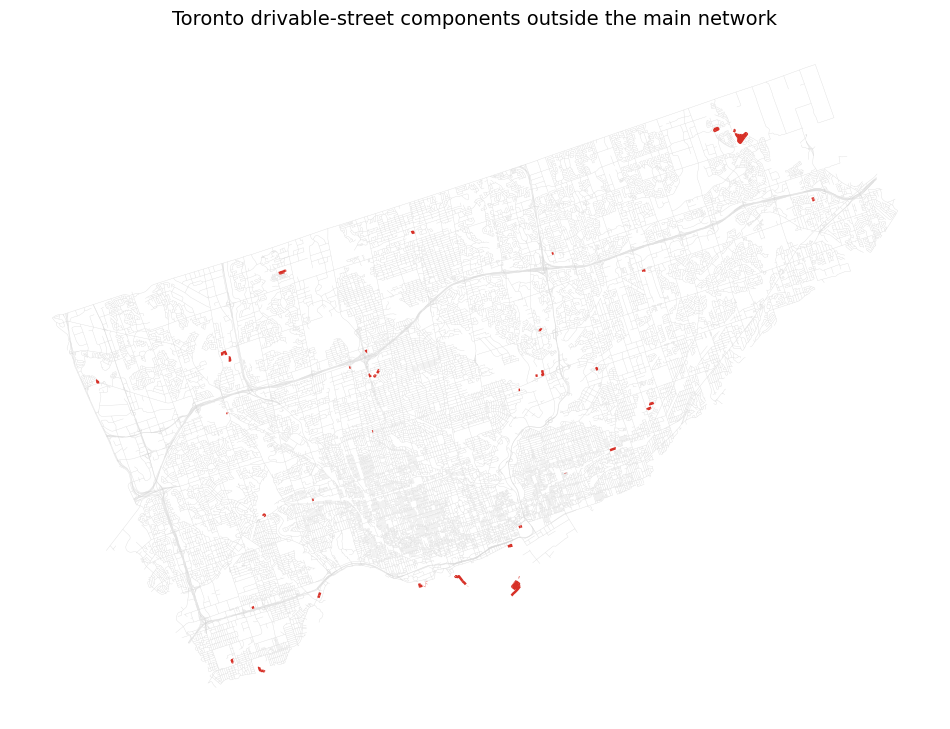

In [7]:
import matplotlib.pyplot as plt

small_component_edges = component_edges[
    component_edges["component_id"] != 1
].copy()

fig, ax = plt.subplots(figsize=(12, 12))

component_edges[
    component_edges["component_id"] == 1
].plot(
    ax=ax,
    color="#d9d9d9",
    linewidth=0.25,
)

small_component_edges.plot(
    ax=ax,
    color="#d73027",
    linewidth=1.8,
)

ax.set_title(
    "Toronto drivable-street components outside the main network",
    fontsize=14,
)
ax.set_axis_off()

plt.show()

In [8]:
largest_small_component_ids = (
    component_summary.drop(index=1)
    .head(8)
    .index
)

component_details = (
    small_component_edges[
        small_component_edges["component_id"].isin(
            largest_small_component_ids
        )
    ]
    .groupby("component_id")
    .agg(
        street_labels=(
            "street_label",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        feature_types=(
            "feature_desc",
            lambda values: sorted(set(values)),
        ),
    )
)

display(component_details)

,street_labels,feature_types
component_id,,
2,"[Algonquin Bridge Rd, Cibola Ave, Dacotah Ave,...",[Laneway]
3,"[Gristone Cres, Knowles Dr, Loggerhead Grv, Os...",[Local]
4,"[Ln E Haynes S Assiniboine, Ln N Cook E Haynes...",[Laneway]
5,"[Dairy Dr, Ethel Bell Ter, John Bell Cres]",[Local]
6,[Ontario Place Bridge],[Other]
7,[Col Smith Waterfront],[Access Road]
8,[Island Airport],[Access Road]
14,[Bagot Crt],[Laneway]


In [9]:
from src.cleaning import load_centerline, standardize_centerline

raw_centerline = standardize_centerline(
    load_centerline(data_path)
)

excluded_edges = raw_centerline[
    ~raw_centerline["feature_desc"].isin(
        DRIVABLE_STREET_FEATURES
    )
].copy()

excluded_edges["from_component"] = excluded_edges[
    "from_intersection_id"
].map(node_to_component)

excluded_edges["to_component"] = excluded_edges[
    "to_intersection_id"
].map(node_to_component)

touching_excluded_edges = excluded_edges[
    excluded_edges["from_component"].notna()
    | excluded_edges["to_component"].notna()
].copy()

components_to_investigate = [2, 3, 4, 5, 6, 7, 8, 14]

component_connections = touching_excluded_edges[
    touching_excluded_edges["from_component"].isin(
        components_to_investigate
    )
    | touching_excluded_edges["to_component"].isin(
        components_to_investigate
    )
][
    [
        "centerline_id",
        "street_label",
        "feature_desc",
        "from_intersection_id",
        "to_intersection_id",
        "from_component",
        "to_component",
    ]
].sort_values(
    ["from_component", "to_component", "feature_desc"],
    na_position="last",
)

display(component_connections)

,centerline_id,street_label,feature_desc,from_intersection_id,to_intersection_id,from_component,to_component
19037,30024801,Boake St,Pending,20145306,30024800,1.0,4.0
19038,30024804,Haynes Ave,Pending,20015457,30024803,1.0,4.0
19042,30024807,Hackett Ave,Pending,20145297,30024806,1.0,4.0
18291,30012958,Bell Estate Rd,Pending,20237164,30012908,1.0,5.0
24304,1147603,Toronto Islands,Major Shoreline,13469332,13469071,2.0,NaN
24305,3814303,Algonquin Island,Major Shoreline,13469323,13469493,2.0,NaN
27342,30090046,Cibola Ave,Trail,13469567,30090045,2.0,NaN
29339,30096852,Algonquin Island Park Trl,Trail,30096844,30096851,2.0,NaN
28931,30095235,Staines Rd,Pending,14252616,30095234,3.0,NaN
31493,30105581,Staines Rd,Pending,14252582,30105580,3.0,NaN


In [10]:
pending_scenario_features = (
    set(DRIVABLE_STREET_FEATURES)
    | {"Pending"}
)

pending_edges, pending_cleaning_report = prepare_street_edges(
    raw_centerline,
    included_features=pending_scenario_features,
)

pending_graph = build_street_graph(pending_edges)
pending_network_report = summarize_network(pending_graph)

pending_components = sorted(
    nx.weakly_connected_components(pending_graph),
    key=len,
    reverse=True,
)
pending_main_component = pending_components[0]

pending_effect = []

for component_id in components_to_investigate:
    original_nodes = components[component_id - 1]
    nodes_joining_main = len(
        original_nodes.intersection(pending_main_component)
    )

    pending_effect.append(
        {
            "component_id": component_id,
            "original_nodes": len(original_nodes),
            "nodes_joining_main": nodes_joining_main,
            "fully_joins_main": (
                nodes_joining_main == len(original_nodes)
            ),
        }
    )

pending_effect = pd.DataFrame(pending_effect)

display(
    pd.Series(
        asdict(pending_network_report),
        name="with_pending",
    ).to_frame()
)
display(pending_effect)


,with_pending
nodes,36295.000
directed_edges,94508.000
source_segments,50269.000
weakly_connected_components,13.000
largest_component_nodes,36250.000
largest_component_pct,99.880
self_loop_source_segments,92.000
one_way_source_segments,5985.000
total_source_length_km,6464.024
node_ids_with_endpoint_spread_over_1m,1.000


,component_id,original_nodes,nodes_joining_main,fully_joins_main
0,2,17,0,False
1,3,13,13,True
2,4,10,10,True
3,5,6,6,True
4,6,5,0,False
5,7,5,5,True
6,8,5,0,False
7,14,4,4,True


In [11]:
pending_node_to_component = {
    node_id: component_id
    for component_id, nodes in enumerate(
        pending_components,
        start=1,
    )
    for node_id in nodes
}

pending_component_edges = pending_edges.copy()

pending_component_edges["component_id"] = (
    pending_component_edges["from_intersection_id"]
    .map(pending_node_to_component)
)

pending_component_summary = (
    pending_component_edges.groupby("component_id")
    .agg(
        node_count=(
            "from_intersection_id",
            lambda values: len(
                set(values)
            ),
        ),
        source_segments=("centerline_id", "size"),
        total_length_km=(
            "length_m",
            lambda values: round(
                values.sum() / 1_000,
                3,
            ),
        ),
        street_labels=(
            "street_label",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        feature_types=(
            "feature_desc",
            lambda values: sorted(set(values)),
        ),
    )
)

pending_component_summary["node_count"] = [
    len(pending_components[component_id - 1])
    for component_id in pending_component_summary.index
]

display(
    pending_component_summary
    .drop(index=1)
    .sort_values("node_count", ascending=False)
)

,node_count,source_segments,total_length_km,street_labels,feature_types
component_id,,,,,
2,17,20,2.457,"[Algonquin Bridge Rd, Cibola Ave, Dacotah Ave,...",[Laneway]
3,5,4,0.353,[Ontario Place Bridge],[Other]
4,5,5,0.797,[Island Airport],[Access Road]
5,2,1,0.024,[Ln 1 E Unity Rd N Torbrick],[Laneway]
6,2,1,0.075,[Ln S Ryding E Runnymede],[Laneway]
7,2,1,0.031,[Withrow St],[Local]
8,2,1,0.017,[Ontario Place Bridge],[Other]
9,2,1,0.008,[Lakeshore Ave],[Local]
10,2,1,0.044,[Ln N Eglinton W Times],[Laneway]


In [12]:
import geopandas as gpd

pending_main_edges = pending_component_edges[
    pending_component_edges["component_id"] == 1
][
    ["centerline_id", "street_label", "geometry"]
].copy()

isolated_component_geometries = (
    pending_component_edges[
        pending_component_edges["component_id"] != 1
    ]
    .dissolve(by="component_id")
    .reset_index()
    [["component_id", "geometry"]]
)

nearest_main_edges = gpd.sjoin_nearest(
    isolated_component_geometries,
    pending_main_edges,
    how="left",
    distance_col="nearest_main_distance_m",
)

nearest_main_edges = (
    nearest_main_edges.sort_values(
        ["component_id", "nearest_main_distance_m"]
    )
    .drop_duplicates("component_id")
    .rename(
        columns={
            "centerline_id": "nearest_centerline_id",
            "street_label": "nearest_street",
        }
    )
    [
        [
            "component_id",
            "nearest_main_distance_m",
            "nearest_centerline_id",
            "nearest_street",
        ]
    ]
)

nearest_main_edges["nearest_main_distance_m"] = (
    nearest_main_edges["nearest_main_distance_m"].round(2)
)

display(
    pending_component_summary
    .drop(index=1)
    .join(nearest_main_edges.set_index("component_id"))
    [
        [
            "node_count",
            "source_segments",
            "total_length_km",
            "street_labels",
            "feature_types",
            "nearest_main_distance_m",
            "nearest_street",
        ]
    ]
)

,node_count,source_segments,total_length_km,street_labels,feature_types,nearest_main_distance_m,nearest_street
component_id,,,,,,,
2,17,20,2.457,"[Algonquin Bridge Rd, Cibola Ave, Dacotah Ave,...",[Laneway],1177.07,Unwin Ave
3,5,4,0.353,[Ontario Place Bridge],[Other],108.48,Remembrance Dr
4,5,5,0.797,[Island Airport],[Access Road],183.57,Eireann Quay
5,2,1,0.024,[Ln 1 E Unity Rd N Torbrick],[Laneway],3.01,Ln N Torbrick E Unity Rd
6,2,1,0.075,[Ln S Ryding E Runnymede],[Laneway],13.40,Runnymede Rd
7,2,1,0.031,[Withrow St],[Local],963.75,Unwin Ave
8,2,1,0.017,[Ontario Place Bridge],[Other],55.06,Remembrance Dr
9,2,1,0.008,[Lakeshore Ave],[Local],963.82,Eireann Quay
10,2,1,0.044,[Ln N Eglinton W Times],[Laneway],24.83,Times Rd


In [13]:
main_component_nodes = max(
    nx.weakly_connected_components(street_graph),
    key=len,
)

main_directed_graph = street_graph.subgraph(
    main_component_nodes
).copy()

analysis_graph = nx.Graph()
analysis_graph.add_nodes_from(
    main_directed_graph.nodes(data=True)
)

for start, end, attributes in main_directed_graph.edges(
    data=True
):
    if start == end:
        continue

    source_id = attributes["source_centerline_id"]
    length_m = float(attributes["length_m"])

    if analysis_graph.has_edge(start, end):
        existing = analysis_graph[start][end]
        existing["source_centerline_ids"].add(source_id)
        existing["length_m"] = min(
            existing["length_m"],
            length_m,
        )
    else:
        analysis_graph.add_edge(
            start,
            end,
            length_m=length_m,
            source_centerline_ids={source_id},
        )

assert nx.is_connected(analysis_graph)
assert nx.number_of_selfloops(analysis_graph) == 0

analysis_graph_summary = {
    "nodes": analysis_graph.number_of_nodes(),
    "edges": analysis_graph.number_of_edges(),
    "connected": nx.is_connected(analysis_graph),
    "self_loops": nx.number_of_selfloops(
        analysis_graph
    ),
}

display(
    pd.Series(
        analysis_graph_summary,
        name="value",
    ).to_frame()
)


,value
nodes,35788
edges,48817
connected,True
self_loops,0


In [14]:
main_source_edges = component_edges[
    component_edges["component_id"] == 1
].copy()

main_self_loop_ids = set(
    main_source_edges.loc[
        main_source_edges["from_intersection_id"]
        == main_source_edges["to_intersection_id"],
        "centerline_id",
    ]
)

represented_source_ids = set().union(
    *[
        attributes["source_centerline_ids"]
        for _, _, attributes in analysis_graph.edges(
            data=True
        )
    ]
)

expected_source_ids = (
    set(main_source_edges["centerline_id"])
    - main_self_loop_ids
)

assert represented_source_ids == expected_source_ids

parallel_edge_groups = sum(
    len(attributes["source_centerline_ids"]) > 1
    for _, _, attributes in analysis_graph.edges(
        data=True
    )
)

extra_parallel_segments = sum(
    len(attributes["source_centerline_ids"]) - 1
    for _, _, attributes in analysis_graph.edges(
        data=True
    )
)

collapse_summary = {
    "main_source_segments": len(main_source_edges),
    "removed_self_loop_segments": len(
        main_self_loop_ids
    ),
    "represented_source_segments": len(
        represented_source_ids
    ),
    "simple_graph_edges": (
        analysis_graph.number_of_edges()
    ),
    "parallel_edge_groups": parallel_edge_groups,
    "extra_parallel_segments": (
        extra_parallel_segments
    ),
}

display(
    pd.Series(
        collapse_summary,
        name="value",
    ).to_frame()
)

,value
main_source_segments,49442
removed_self_loop_segments,92
represented_source_segments,49350
simple_graph_edges,48817
parallel_edge_groups,532
extra_parallel_segments,533


In [15]:
degree_by_node = pd.Series(
    dict(analysis_graph.degree()),
    name="degree",
)

assert (
    degree_by_node.sum()
    == 2 * analysis_graph.number_of_edges()
)

degree_distribution = (
    degree_by_node.value_counts()
    .sort_index()
    .rename_axis("degree")
    .reset_index(name="node_count")
)

degree_distribution["node_pct"] = (
    degree_distribution["node_count"]
    / analysis_graph.number_of_nodes()
    * 100
).round(2)

degree_summary = {
    "nodes": analysis_graph.number_of_nodes(),
    "minimum_degree": int(degree_by_node.min()),
    "median_degree": float(degree_by_node.median()),
    "mean_degree": round(
        float(degree_by_node.mean()),
        3,
    ),
    "maximum_degree": int(degree_by_node.max()),
    "terminal_nodes_degree_1": int(
        (degree_by_node == 1).sum()
    ),
    "through_nodes_degree_2": int(
        (degree_by_node == 2).sum()
    ),
    "junction_nodes_degree_3_plus": int(
        (degree_by_node >= 3).sum()
    ),
}

display(
    pd.Series(
        degree_summary,
        name="value",
    ).to_frame()
)

display(degree_distribution)

,value
nodes,35788.000
minimum_degree,1.000
median_degree,3.000
mean_degree,2.728
maximum_degree,6.000
terminal_nodes_degree_1,4824.000
through_nodes_degree_2,6382.000
junction_nodes_degree_3_plus,24582.000


,degree,node_count,node_pct
0,1,4824,13.48
1,2,6382,17.83
2,3,18415,51.46
3,4,6047,16.90
4,5,107,0.30
5,6,13,0.04


In [16]:
high_degree_ids = set(
    degree_by_node[
        degree_by_node >= 5
    ].index
)

edge_endpoints = pd.concat(
    [
        main_source_edges[
            [
                "centerline_id",
                "street_label",
                "feature_desc",
                "from_intersection_id",
            ]
        ].rename(
            columns={
                "from_intersection_id":
                    "intersection_id"
            }
        ),
        main_source_edges[
            [
                "centerline_id",
                "street_label",
                "feature_desc",
                "to_intersection_id",
            ]
        ].rename(
            columns={
                "to_intersection_id":
                    "intersection_id"
            }
        ),
    ],
    ignore_index=True,
)

high_degree_details = (
    edge_endpoints[
        edge_endpoints["intersection_id"].isin(
            high_degree_ids
        )
    ]
    .groupby("intersection_id")
    .agg(
        source_segments=(
            "centerline_id",
            "nunique",
        ),
        street_labels=(
            "street_label",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        feature_types=(
            "feature_desc",
            lambda values: sorted(set(values)),
        ),
    )
    .join(
        degree_by_node.rename_axis(
            "intersection_id"
        )
    )
    .sort_values(
        ["degree", "source_segments"],
        ascending=False,
    )
)

display(high_degree_details)

,source_segments,street_labels,feature_types,degree
intersection_id,,,,
13460573,8,"[27 N Dixon W Ramp, Dixon E 27 N Ramp, Dixon R...","[Major Arterial, Major Arterial Ramp]",6
13454202,7,"[Eglinton Ave E, Eglinton E Wynford Dr Ramp, W...","[Major Arterial, Major Arterial Ramp, Minor Ar...",6
13453585,6,"[Allen Rd, Allen S 401 C E Ramp, Highway 401]","[Expressway, Expressway Ramp]",6
13453685,6,"[Allen Rd, Allen S 401 C E Ramp, Highway 401]","[Expressway, Expressway Ramp]",6
13455995,6,"[401 C E 400 N Ramp, 401 C W 400 S Ramp, 401 E...","[Expressway, Expressway Ramp]",6
...,...,...,...,...
13470060,5,"[Gardiner X W 427 X N Ramp, Gardiner X W Brown...","[Expressway Ramp, Minor Arterial]",5
13470102,5,"[Browns Li N 427 C N Ramp, Evans W 427 C N Ram...","[Expressway, Expressway Ramp]",5
13470208,5,"[427 C S Qew X W Ramp, Evans Ave, QEW]","[Expressway, Expressway Ramp, Major Arterial]",5


In [17]:
from time import perf_counter

BETWEENNESS_SAMPLE_SIZE = 500
BETWEENNESS_SEED = 42

started_at = perf_counter()

betweenness = nx.betweenness_centrality(
    analysis_graph,
    k=BETWEENNESS_SAMPLE_SIZE,
    normalized=True,
    weight="length_m",
    endpoints=False,
    seed=BETWEENNESS_SEED,
)

elapsed_seconds = perf_counter() - started_at

betweenness_by_node = pd.Series(
    betweenness,
    name="betweenness",
)

assert len(betweenness_by_node) == (
    analysis_graph.number_of_nodes()
)
assert betweenness_by_node.notna().all()
assert betweenness_by_node.between(0, 1).all()

node_street_context = (
    edge_endpoints.groupby("intersection_id")
    .agg(
        street_labels=(
            "street_label",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        feature_types=(
            "feature_desc",
            lambda values: sorted(set(values)),
        ),
    )
)

top_betweenness = (
    betweenness_by_node
    .nlargest(20)
    .rename_axis("intersection_id")
    .to_frame()
    .join(
        degree_by_node.rename_axis(
            "intersection_id"
        )
    )
    .join(node_street_context)
)

top_betweenness["betweenness"] = (
    top_betweenness["betweenness"].round(6)
)

run_summary = {
    "sample_size": BETWEENNESS_SAMPLE_SIZE,
    "seed": BETWEENNESS_SEED,
    "elapsed_seconds": round(elapsed_seconds, 2),
    "nodes_scored": len(betweenness_by_node),
    "nonzero_nodes": int(
        (betweenness_by_node > 0).sum()
    ),
}

display(
    pd.Series(run_summary, name="value").to_frame()
)
display(top_betweenness)

,value
sample_size,500.00
seed,42.00
elapsed_seconds,45.96
nodes_scored,35788.00
nonzero_nodes,30275.00


,betweenness,degree,street_labels,feature_types
intersection_id,,,,
13463022,0.127542,4,"[Bloor St E, Rosedale Valley Rd]","[Major Arterial, Minor Arterial]"
13462475,0.109994,4,"[DVP, Prince Edward Viaduct]","[Expressway, Major Arterial]"
13462592,0.104916,4,"[Bayview Ave, Prince Edward Viaduct]",[Major Arterial]
30003677,0.104417,2,[Prince Edward Viaduct],[Major Arterial]
13462572,0.104408,2,[Prince Edward Viaduct],[Major Arterial]
13462540,0.104402,2,[Prince Edward Viaduct],[Major Arterial]
30003616,0.104397,2,[Prince Edward Viaduct],[Major Arterial]
13462482,0.104394,2,[Prince Edward Viaduct],[Major Arterial]
13462709,0.104135,3,"[Bloor St E, Drumsnab Rd]","[Local, Major Arterial]"
